<a href="https://colab.research.google.com/github/kunwar162/DualLensAnalytics/blob/main/DualLens_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install Libraries

!pip install langchain==0.3.25 \
              langchain-core==0.3.65 \
              langchain-openai==0.3.24 \
              chromadb==1.3.4 \
              langchain-community==0.3.20 \
              pypdf==5.4.0



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of langchain-text-splitters to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.1/438.1 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# New Section

In [1]:
import yfinance as yf              # Used for gathering stock prices
import matplotlib.pyplot as plt    # Used for Data Visualization / Plots / Graphs
import pandas as pd                # Helpful for working with tabular data like DataFrames
import os                          # Interacting with the operating system

from langchain.text_splitter import RecursiveCharacterTextSplitter      #  Helpful in splitting the PDF into smaller chunks

from langchain_community.document_loaders import PyPDFDirectoryLoader, PyPDFLoader     # Loading a PDF
from langchain_community.vectorstores import Chroma    # Vector DataBase

In [2]:
companies = ["GOOGL", "MSFT", "IBM", "NVDA", "AMZN"]

In [4]:
#Loading the `config.json` file
import json
import os

# Load the JSON file and extract values
file_name = "Configuration/config.json"
with open(file_name, 'r') as file:
    config = json.load(file)
    os.environ['OPENAI_API_KEY'] = config["API_KEY"] # Loading the API Key
    os.environ["OPENAI_BASE_URL"] = config["OPENAI_API_BASE"] # Loading the API Base Url

In [5]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model="gpt-4o-mini",                      # "gpt-4o-mini" to be used as an LLM
    temperature="0",                # Set the temprature to 0
    max_tokens="5000",                 # Set the max_tokens = 5000, so that the long response will not be clipped off
    top_p=0.95,
    frequency_penalty=1.2,
    stop_sequences=['INST']
)

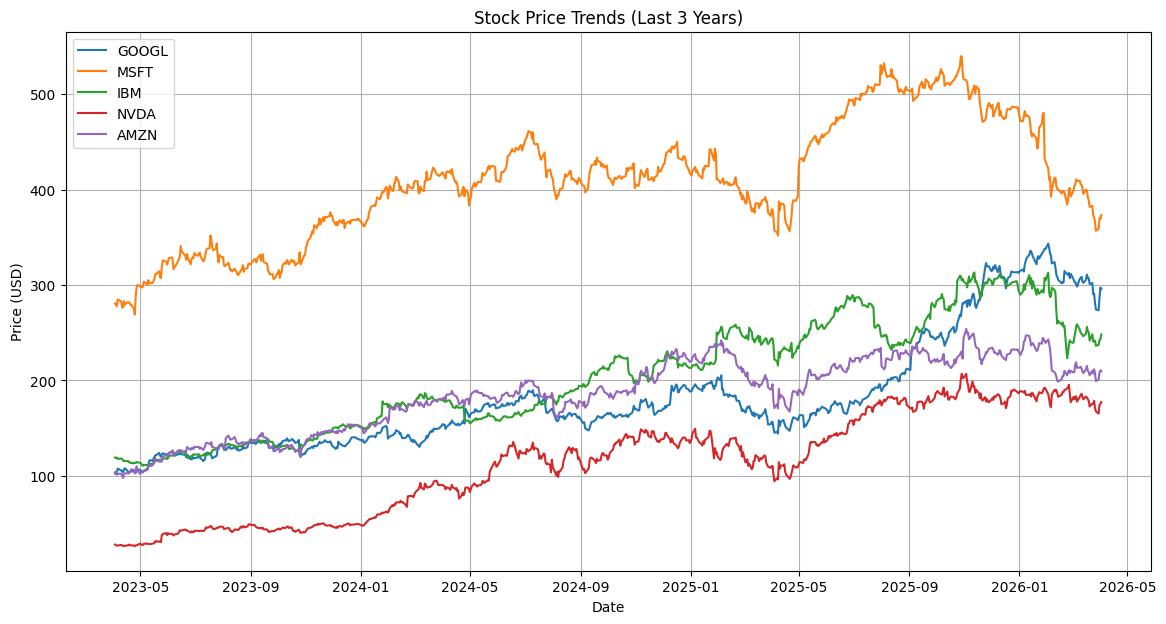

In [6]:
plt.figure(figsize=(14,7))

# Loop through each company and plot closing prices
for symbol in companies:
    ticker = yf.Ticker(symbol)
    data = ticker.history(period="3y")

    # Plot closing price
    plt.plot(data.index, data['Close'], label=symbol)

plt.title("Stock Price Trends (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.savefig("Stock_Price_Trends_3Y.png")
plt.show()

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

companies = ["GOOGL", "MSFT", "IBM", "NVDA", "AMZN"]
metrics_list = {}

# Fetching the financial metrics
for symbol in companies:                          # Loop through all the companies
    ticker = yf.Ticker(symbol)
    info = ticker.info
    metrics_list[symbol] = {                              # Define the dictionary of all the Finanical Metrics
        "Market Cap": info.get("marketCap", 0),
        "P/E Ratio": info.get("trailingPE", 0),
        "Dividend Yield": info.get("dividendYield", 0),
        "Beta": info.get("beta", 0),
        "Total Revenue": info.get("totalRevenue", 0)
    }
                        # Define the dictionary of all the Finanical Metrics


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

companies = ["GOOGL"]
metrics_list = {}

# Fetching the financial metrics
for symbol in "--- --- ---":                          # Loop through all the companies
    ticker = yf.Ticker("--- --- ---")
    info = ticker.info
    metrics_list[symbol] = {                              # Define the dictionary of all the Finanical Metrics
        "Market Cap": info.get("marketCap", 0),
        "P/E Ratio": info.get("--- --- ---", 0),
        "Dividend Yield": info.get("--- --- ---", 0),
        "Beta": info.get("beta", 0),
        "Total Revenue": info.get("--- --- ---", 0)
    }




In [12]:
# Convert to DataFrame
df = pd.DataFrame(metrics_list)

# Converting large numbers to billions for readability by dividing the whole column by 1e9
df.loc["Market Cap"] = df.loc["Market Cap"] / 1e9
df.loc["Total Revenue"] = df.loc["Total Revenue"] / 1e9
df.loc["Dividend Yield"] = df.loc["Dividend Yield"] * 100  # Convert to percentage

df   # Printing the df

KeyError: 'Market Cap'

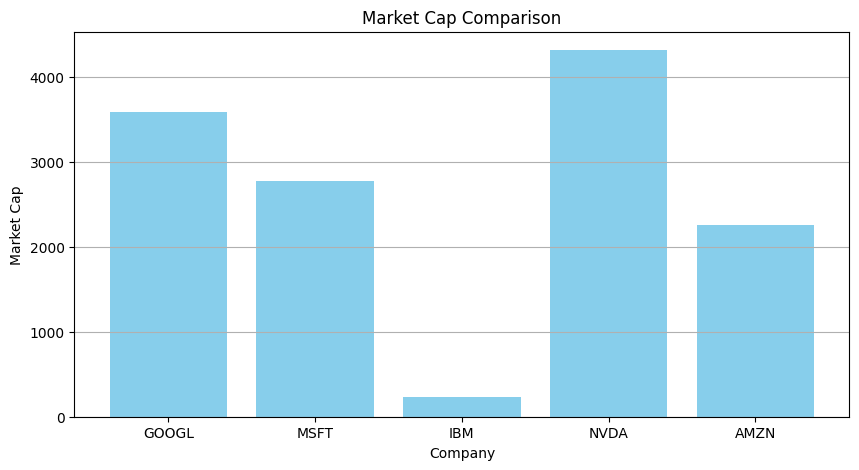

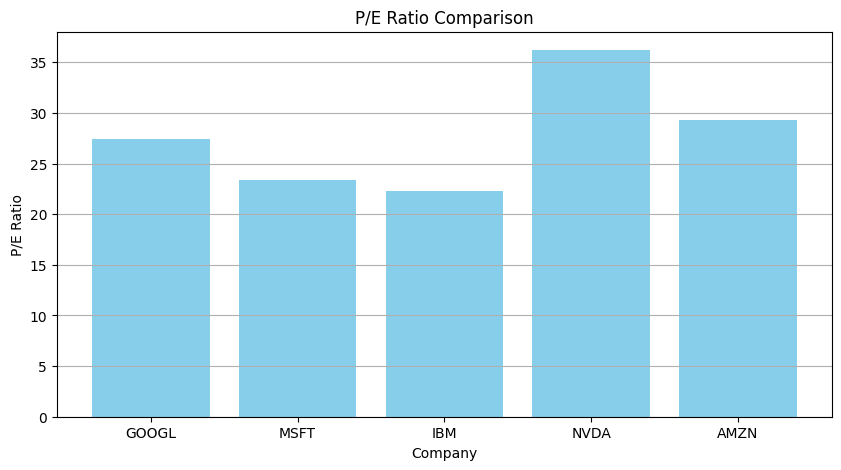

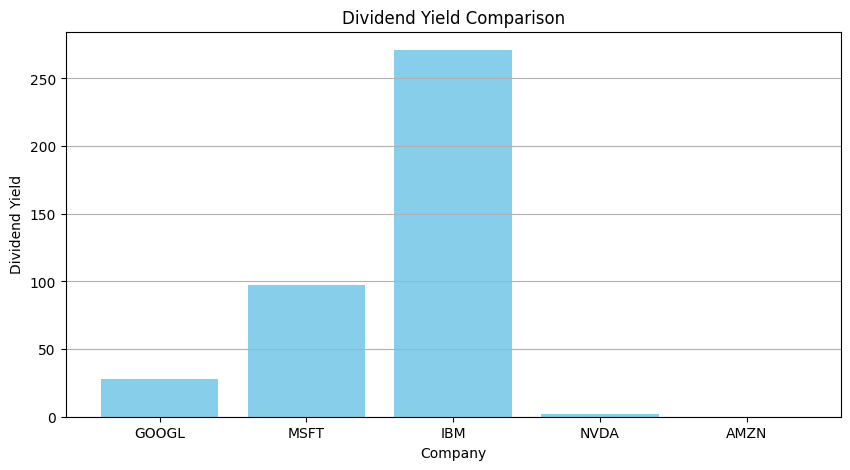

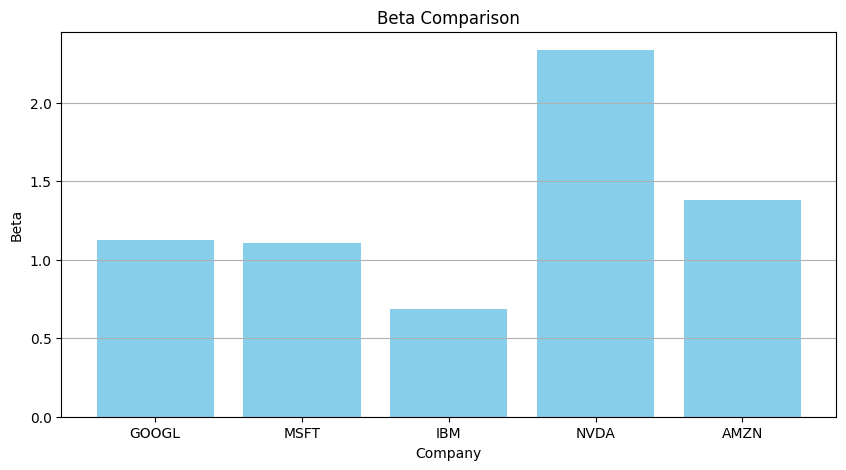

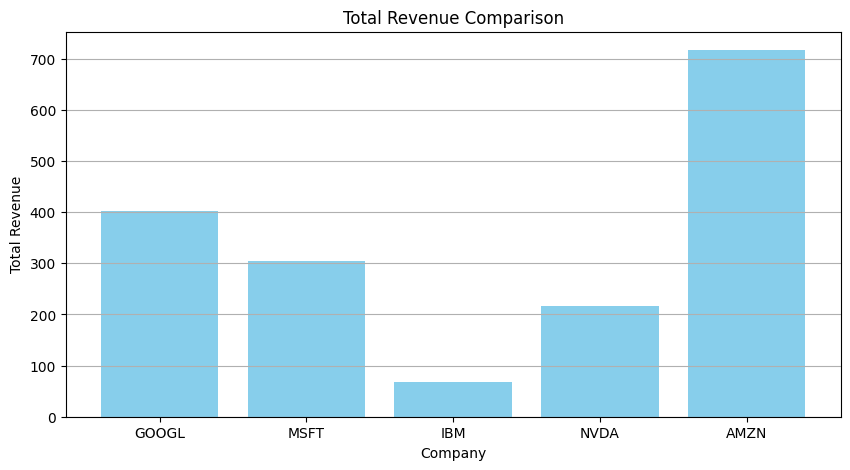

In [ ]:
# Plot each metric as a separate bar graph
metrics_to_plot = ["Market Cap", "P/E Ratio", "Dividend Yield", "Beta", "Total Revenue"]

for metric in metrics_to_plot:
    plt.figure(figsize=(10,5))
    plt.bar(df.columns, df.loc[metric], color='skyblue') # Re-applying the corrected line
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.xlabel("Company")
    plt.grid(axis='y')
    plt.show()

In [ ]:
#RAG Read
import zipfile
file_name="Data/Companies-AI-Initiatives.zip"
with zipfile.ZipFile(file_name, 'r') as zip_ref:
  zip_ref.extractall("/content/")         # Storing all the unzipped contents in this location

In [ ]:
# Path of all AI Initiative Documents
ai_initiative_pdf_paths = [f"Companies-AI-Initiatives/{file}" for file in os.listdir("/content/Companies-AI-Initiatives")]
ai_initiative_pdf_paths

['Companies-AI-Initiatives/GOOGL.pdf',
 'Companies-AI-Initiatives/AMZN.pdf',
 'Companies-AI-Initiatives/IBM.pdf',
 'Companies-AI-Initiatives/MSFT.pdf',
 'Companies-AI-Initiatives/NVDA.pdf']

In [ ]:
from langchain_community.document_loaders import PyPDFDirectoryLoader
loader = PyPDFDirectoryLoader(path = "Companies-AI-Initiatives/")          # Creating an PDF loader object

In [ ]:
# Defining the text splitter
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=1000,
    chunk_overlap=200
)

NameError: name 'RecursiveCharacterTextSplitter' is not defined